# Projet 9 — Lapage : Analyse e-commerce

**Période analysée :** mars 2021 – février 2023  
**Source :** 3 fichiers CSV (customers, products, transactions)

---

## Sommaire

### 1. [Nettoyage des données](#1-nettoyage)
- 1.1 Customers
- 1.2 Products
- 1.3 Transactions

### 2. [Analyses Annabelle — KPIs & indicateurs commerciaux](#2-annabelle)
- 2.1 CA mensuel & panier moyen
- 2.2 Nouveaux clients vs récurrents par mois
- 2.3 Nombre de transactions par mois
- 2.4 Références distinctes vendues par mois
- 2.5 Top 10 / Flop 10 produits
- 2.6 Règle de Pareto — quels produits font 80 % du CA ?
- 2.7 CA BtoB (proxy : clients à fort volume)
- 2.8 Courbe de Lorenz — concentration du CA
- 2.9 Top 20 clients — qui sont-ils ?
- 2.10 Que consomment les top clients ?
- 2.11 Clients one-shot vs récurrents
- 2.12 Segmentation RFM
- 2.13 Cohortes — taux de rétention mensuelle
- 2.14 Temporalité des achats
- 2.15 Panier moyen & volume de ventes par catégorie
- 2.16 Profil genre par catégorie
- 2.17 Âge par catégorie achetée (boxplot)
- 2.18 Top 10 produits vendus par catégorie

### 3. [Analyses Julie — Corrélations comportementales](#3-julie)
- 3.1 Genre ↔ Catégorie achetée (Chi²)
- 3.2 Tranche d'âge ↔ Catégorie achetée (Chi²)
- 3.3 Âge ↔ CA total (Pearson)
- 3.4 Âge ↔ Fréquence d'achat (Pearson)
- 3.5 Âge ↔ Panier moyen (Pearson)
- 3.6 Ancienneté ↔ CA total (Pearson)
- 3.7 Ancienneté ↔ Panier moyen (Pearson)
- 3.8 Fréquence d'achat ↔ Panier moyen (Pearson)
- 3.9 Délai moyen entre commandes ↔ CA total (Pearson)
- 3.10 Genre ↔ Panier moyen (Mann-Whitney)
- 3.11 Tranche d'âge ↔ Panier moyen (Kruskal-Wallis)

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
from scipy import stats

DATA_DIR = Path("DAN-P6-donnees/DAN-P6-donnees")
CLEAN_DIR = Path("data_clean")
FIG_DIR = Path("figures")
CLEAN_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

---
## 1. Nettoyage des données <a id='1-nettoyage'></a>

### 1.1 Customers

In [2]:
customers_raw = pd.read_csv(DATA_DIR / "customers.csv")
print(f"customers brut : {len(customers_raw):,} lignes")
print(customers_raw.dtypes)
customers_raw.head()

customers brut : 8,623 lignes
client_id      str
sex            str
birth        int64
dtype: object


,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943


In [3]:
# Clé primaire
print(customers_raw["client_id"].nunique() == len(customers_raw))

# Doublons
customers_raw.duplicated().sum()

True


np.int64(0)

In [4]:
# Valeurs nulles
customers_raw.isnull().sum()

client_id    0
sex          0
birth        0
dtype: int64

In [5]:
# Valeurs abberantes
print(customers_raw["birth"].min())
print(customers_raw["birth"].max())

1929
2004


In [6]:
mask_test = customers_raw["client_id"].str.startswith("ct_")
print(f"clients test : {mask_test.sum()}")

customers = customers_raw[~mask_test].copy()
print(f"customers : {len(customers):,} lignes")

clients test : 2
customers : 8,621 lignes


### 1.2 Products

In [7]:
products_raw = pd.read_csv(DATA_DIR / "products.csv")
print(f"products brut : {len(products_raw):,} lignes")
print(products_raw.dtypes)
products_raw.head()

products brut : 3,287 lignes
id_prod        str
price      float64
categ        int64
dtype: object


,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0


In [8]:
# Clé primaire
print(products_raw["id_prod"].nunique() == len(products_raw))

# Doublons
products_raw.duplicated().sum()

True


np.int64(0)

In [9]:
# Valeurs nulles
products_raw.isnull().sum()

id_prod    0
price      0
categ      0
dtype: int64

In [10]:
# Valeurs abberantes
print(products_raw["price"].min())
print(products_raw["price"].max())

-1.0
300.0


In [11]:
mask_test = products_raw["id_prod"] == "T_0"
print(f"lignes test (T_0, prix=-1) : {mask_test.sum()}")

products = products_raw[~mask_test].copy()
print(f"products_clean : {len(products):,} lignes")
print(f"supprimés : {len(products_raw) - len(products)}")

lignes test (T_0, prix=-1) : 1
products_clean : 3,286 lignes
supprimés : 1


### 1.3 Transactions

In [12]:
transactions_raw = pd.read_csv(DATA_DIR / "transactions.csv")
transactions_raw["date"] = pd.to_datetime(transactions_raw["date"], errors="coerce")
print(f"transactions brut : {len(transactions_raw):,} lignes")
print(transactions_raw.dtypes)
transactions_raw.head()

transactions brut : 679,532 lignes
id_prod                  str
date          datetime64[us]
session_id               str
client_id                str
dtype: object


,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232


In [13]:
# Doublons
transactions_raw.duplicated().sum()

np.int64(198)

In [14]:
# Valeurs nulles
transactions_raw.isnull().sum()

id_prod         0
date          200
session_id      0
client_id       0
dtype: int64

In [15]:
# 1. Masquer les clients de test
mask_test = transactions_raw["client_id"].str.startswith("ct_")
print(f"lignes test : {mask_test.sum()}")
transactions = transactions_raw[~mask_test].copy()
print("lignes test masquées")

lignes test : 200
lignes test masquées


In [16]:
transactions.info()

<class 'pandas.DataFrame'>
Index: 679332 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   id_prod     679332 non-null  str           
 1   date        679332 non-null  datetime64[us]
 2   session_id  679332 non-null  str           
 3   client_id   679332 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 38.5 MB


---
## 2. Analyses Annabelle — KPIs & indicateurs commerciaux <a id='2-annabelle'></a>

In [17]:
# Chargement des données nettoyées
tx = pd.read_csv(CLEAN_DIR / "transactions_clean.csv", parse_dates=["date"])
prod = pd.read_csv(CLEAN_DIR / "products_clean.csv")
cust = pd.read_csv(CLEAN_DIR / "customers_clean.csv")

In [18]:
COLORS = ["#2E86AB", "#A23B72", "#F18F01"]
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
DOW_FR = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]

In [19]:
df_full = tx.merge(prod, on="id_prod").merge(cust, on="client_id")
df_full["categ"] = df_full["categ"].astype(str)
df_full["age"] = 2023 - df_full["birth"]
df_full["year_month"] = df_full["date"].dt.to_period("M")
perdues = tx[~tx["id_prod"].isin(prod["id_prod"])]

print(f"Lignes perdues (produit introuvable) : {len(perdues):,}")
print(f"Transactions valides : {len(df_full):,}")
print(f"Clients actifs : {df_full['client_id'].nunique():,}")
print(f"CA total : {df_full['price'].sum():,.0f} €")

Lignes perdues (produit introuvable) : 0
Transactions valides : 679,111
Clients actifs : 8,600
CA total : 11,853,729 €


In [20]:
date_ref = df_full["date"].max()
age_bins = [0, 25, 35, 50, 65, 110]
age_labels = ["<25", "25–34", "35–49", "50–64", "65+"]

### 2.1 CA mensuel & panier moyen

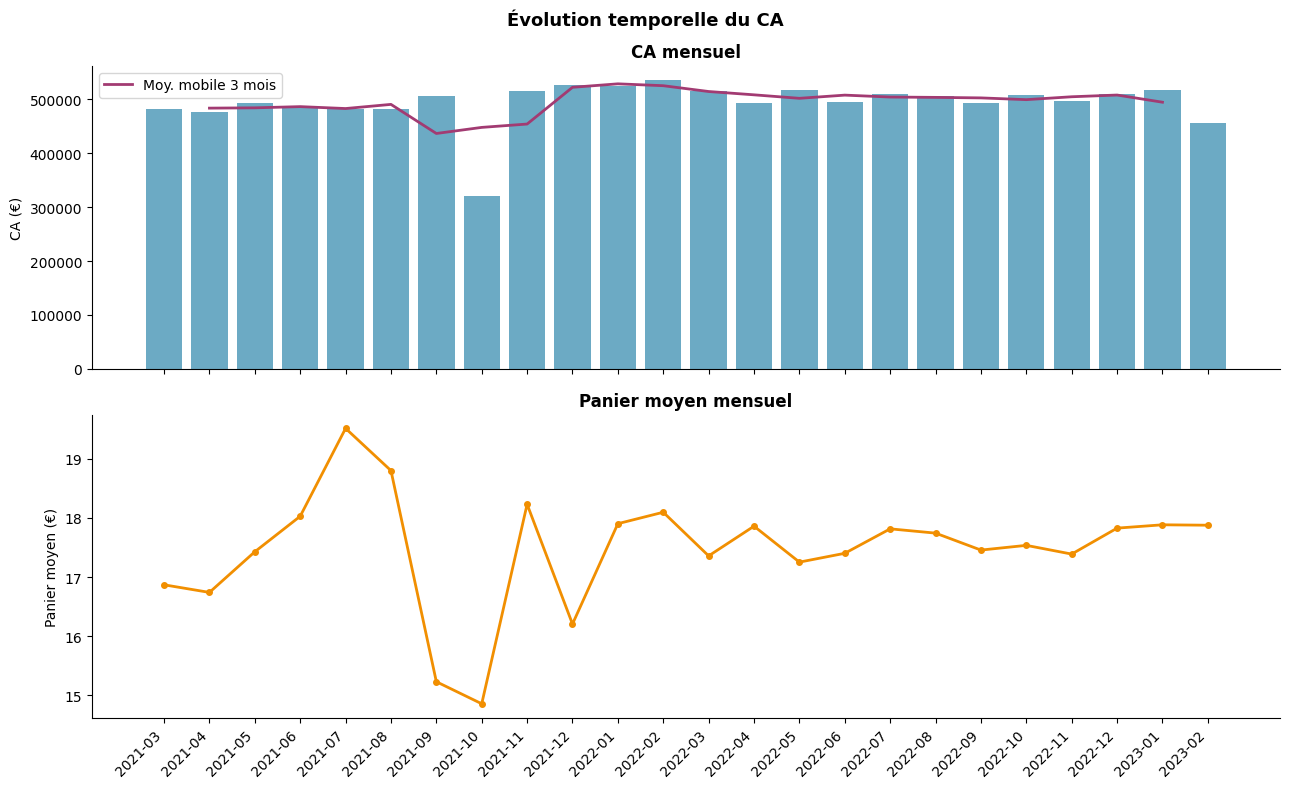

In [21]:
monthly_ca = df_full.groupby("year_month")["price"].agg(
    ca_total="sum", panier_moyen="mean"
).reset_index()
monthly_ca["year_month_str"] = monthly_ca["year_month"].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ma3 = monthly_ca["ca_total"].rolling(3, center=True).mean()
axes[0].bar(range(len(monthly_ca)), monthly_ca["ca_total"], color=COLORS[0], alpha=0.7)
axes[0].plot(range(len(monthly_ca)), ma3, color=COLORS[1], linewidth=2, label="Moy. mobile 3 mois")
axes[0].set_title("CA mensuel", fontweight="bold")
axes[0].set_ylabel("CA (€)")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(range(len(monthly_ca)), monthly_ca["panier_moyen"], color=COLORS[2], linewidth=2, marker="o", markersize=4)
axes[1].set_title("Panier moyen mensuel", fontweight="bold")
axes[1].set_ylabel("Panier moyen (€)")
axes[1].set_xticks(range(len(monthly_ca)))
axes[1].set_xticklabels(monthly_ca["year_month_str"], rotation=45, ha="right")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.suptitle("Évolution temporelle du CA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "01_ca_temporel_synthese.png", dpi=150, bbox_inches="tight")
plt.show()

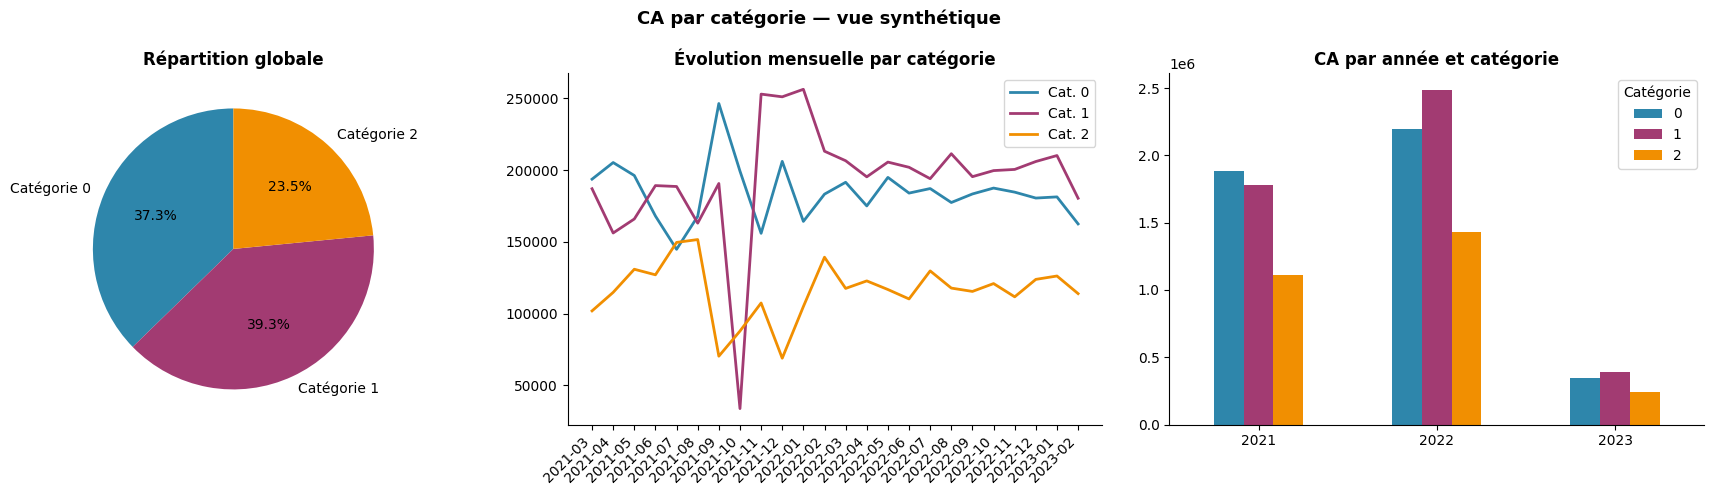

        ca_total  part_pct
categ                     
0      4419731.0      37.3
1      4653722.7      39.3
2      2780275.0      23.5


In [22]:
ca_categ = df_full.groupby("categ")["price"].sum().sort_index()
ca_categ_mensuel = df_full.groupby(["year_month", "categ"])["price"].sum().unstack("categ", fill_value=0)
ca_annee = df_full.groupby([df_full["date"].dt.year, "categ"])["price"].sum().unstack("categ", fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].pie(ca_categ, labels=[f"Catégorie {c}" for c in ca_categ.index],
            colors=COLORS, autopct="%1.1f%%", startangle=90)
axes[0].set_title("Répartition globale", fontweight="bold")

for i, col in enumerate(ca_categ_mensuel.columns):
    axes[1].plot(range(len(ca_categ_mensuel)), ca_categ_mensuel[col],
                 label=f"Cat. {col}", color=COLORS[i], linewidth=2)
axes[1].set_xticks(range(len(ca_categ_mensuel)))
axes[1].set_xticklabels(ca_categ_mensuel.index.astype(str), rotation=45, ha="right")
axes[1].set_title("Évolution mensuelle par catégorie", fontweight="bold")
axes[1].legend()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

ca_annee.plot(kind="bar", ax=axes[2], color=COLORS, rot=0)
axes[2].set_title("CA par année et catégorie", fontweight="bold")
axes[2].set_xlabel("")
axes[2].legend(title="Catégorie")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.suptitle("CA par catégorie — vue synthétique", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_ca_categorie_synthese.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_full.groupby("categ")["price"].agg(
    ca_total="sum", part_pct=lambda x: x.sum() / df_full["price"].sum() * 100
).round(1))

### 2.2 Nouveaux clients vs récurrents par mois

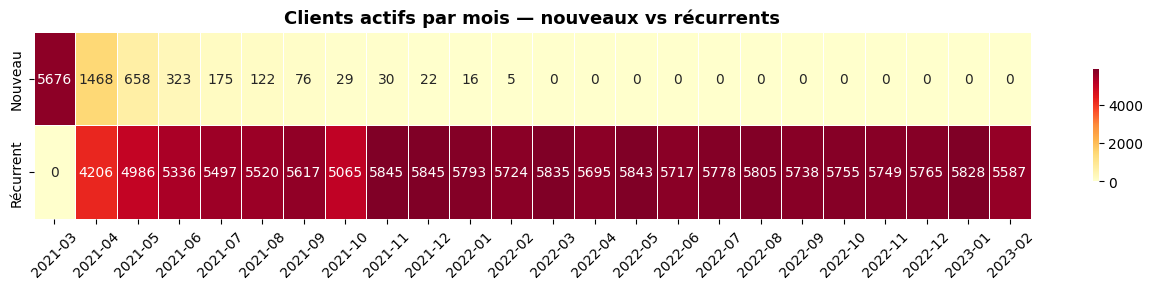

Total clients-mois : 137,129
Dont nouveaux    : 8,600 (6.3%)
Dont récurrents  : 128,529 (93.7%)


In [23]:
premiere_commande = df_full.groupby("client_id")["year_month"].min().rename("cohorte")
df_clients = df_full[["client_id", "year_month"]].drop_duplicates()
df_clients = df_clients.join(premiere_commande, on="client_id")
df_clients["type"] = np.where(df_clients["year_month"] == df_clients["cohorte"], "Nouveau", "Récurrent")

pivot = (
    df_clients.groupby(["type", "year_month"])["client_id"]
    .nunique()
    .unstack("year_month", fill_value=0)
)
pivot.columns = pivot.columns.astype(str)
pivot = pivot.reindex(["Nouveau", "Récurrent"])

fig, ax = plt.subplots(figsize=(13, 3))
sns.heatmap(
    pivot,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.6},
)
ax.set_title("Clients actifs par mois — nouveaux vs récurrents", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_clients_nouveaux_recurrents.png", dpi=150, bbox_inches="tight")
plt.show()

total_new = int(pivot.loc["Nouveau"].sum())
total_rec = int(pivot.loc["Récurrent"].sum())
total = total_new + total_rec
print(f"Total clients-mois : {total:,}")
print(f"Dont nouveaux    : {total_new:,} ({total_new/total*100:.1f}%)")
print(f"Dont récurrents  : {total_rec:,} ({total_rec/total*100:.1f}%)")

### 2.3 Nombre de transactions par mois

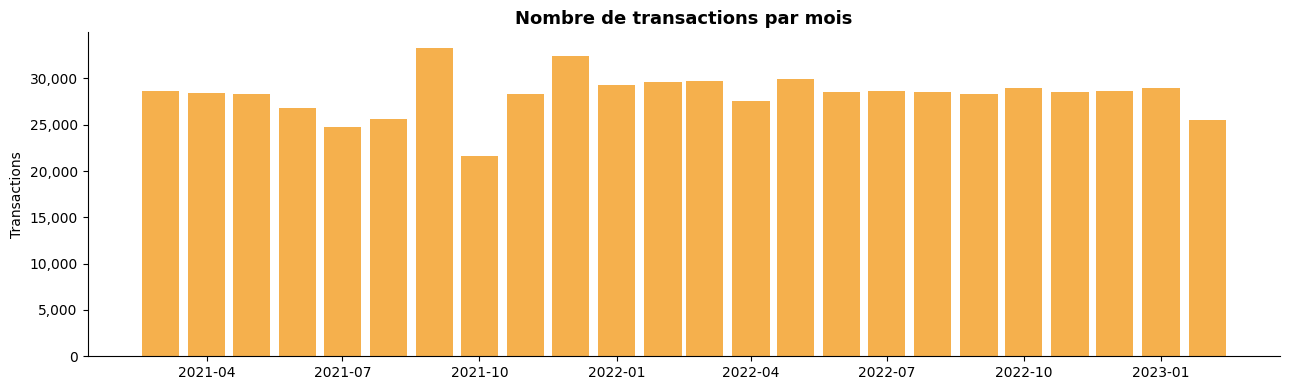

Total transactions année : 679,111
Moyenne/mois : 28,296
Mois record : 2021-09 (33,314)


In [24]:
tx_mois = tx.copy()
tx_mois["year_month"] = tx_mois["date"].dt.to_period("M")
tx_mois = tx_mois.groupby("year_month").size().reset_index(name="n")
tx_mois["date"] = tx_mois["year_month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(tx_mois["date"], tx_mois["n"], width=25, alpha=0.7, color="#F18F01")
ax.set_title("Nombre de transactions par mois", fontsize=13, fontweight="bold")
ax.set_ylabel("Transactions")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_transactions_par_mois.png")
plt.show()

print(f"Total transactions année : {tx_mois['n'].sum():,}")
print(f"Moyenne/mois : {tx_mois['n'].mean():,.0f}")
print(f"Mois record : {tx_mois.loc[tx_mois['n'].idxmax(), 'year_month']} ({tx_mois['n'].max():,})")

### 2.4 Références distinctes vendues par mois

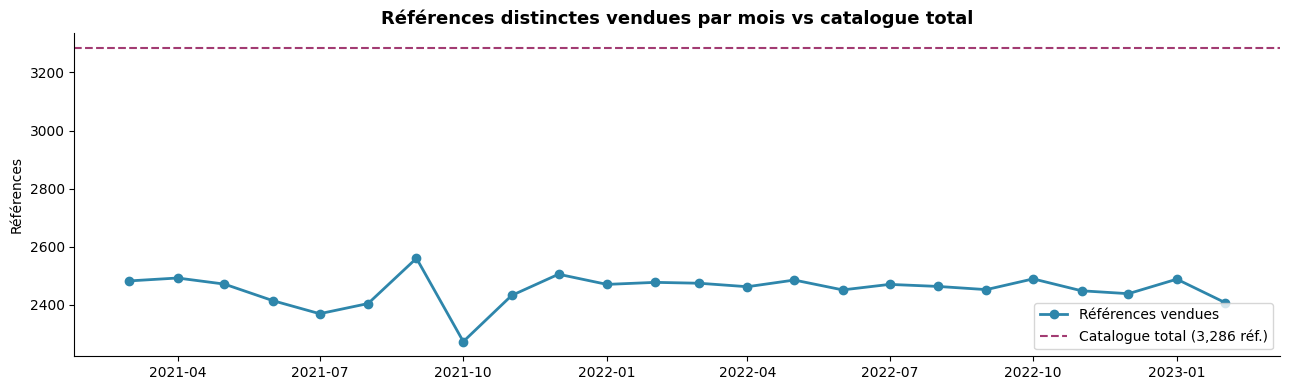

Catalogue total         : 3,286 références
Moyenne vendues/mois    : 2453 (74.7% du catalogue)
Max : 2560 (2021-09)
Min : 2273 (2021-10)

Produits vendus total/mois (moyenne) : 28296


In [25]:
refs_mois = tx.copy()
refs_mois["year_month"] = refs_mois["date"].dt.to_period("M")
refs_mois = refs_mois.groupby("year_month")["id_prod"].agg(
    n="nunique",
    total="count").reset_index()

refs_mois["date"] = refs_mois["year_month"].dt.to_timestamp()

total_catalogue = prod["id_prod"].nunique()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(refs_mois["date"], refs_mois["n"], marker="o", color="#2E86AB", linewidth=2, label="Références vendues")
ax.axhline(total_catalogue, color="#A23B72", linestyle="--", linewidth=1.5, label=f"Catalogue total ({total_catalogue:,} réf.)")
ax.set_title("Références distinctes vendues par mois vs catalogue total", fontsize=13, fontweight="bold")
ax.set_ylabel("Références")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_references_par_mois.png")
plt.show()

print(f"Catalogue total         : {total_catalogue:,} références")
print(f"Moyenne vendues/mois    : {refs_mois['n'].mean():.0f} ({refs_mois['n'].mean()/total_catalogue*100:.1f}% du catalogue)")
print(f"Max : {refs_mois['n'].max()} ({refs_mois.loc[refs_mois['n'].idxmax(), 'year_month']})")
print(f"Min : {refs_mois['n'].min()} ({refs_mois.loc[refs_mois['n'].idxmin(), 'year_month']})")
print(f"\nProduits vendus total/mois (moyenne) : {refs_mois['total'].mean():.0f}")

### 2.5 Top 10 / Flop 10 produits

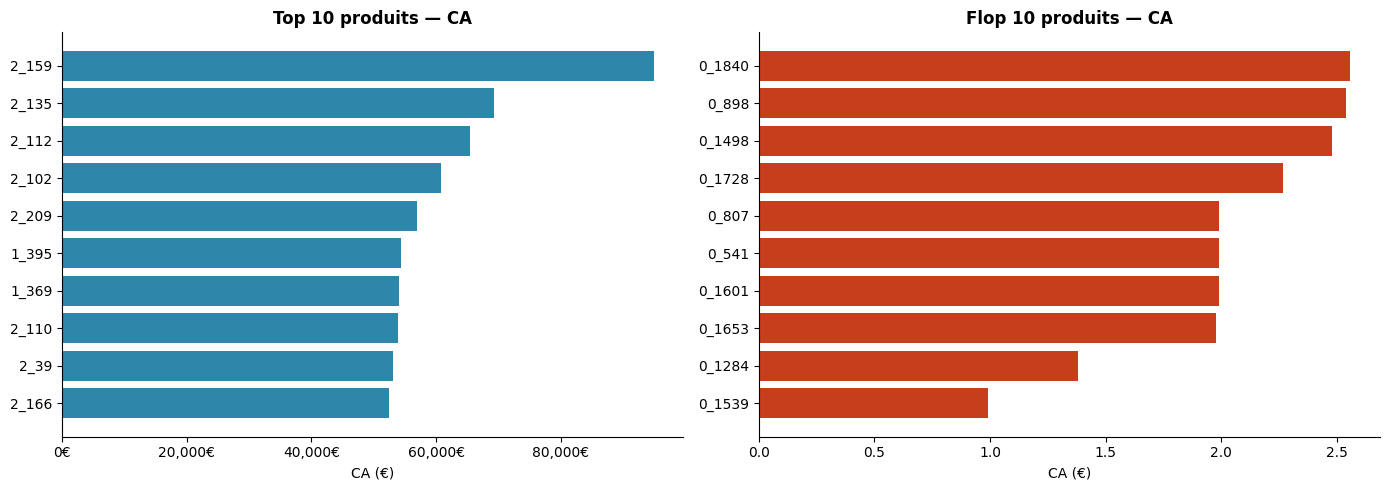

Top 10  : 615,083 € (5.2% du CA)
               ca  ventes
id_prod                  
2_159    94893.50     650
2_135    69334.95    1005
2_112    65407.76     968
2_102    60736.78    1027
2_209    56971.86     814
1_395    54356.25    1875
1_369    54025.48    2252
2_110    53846.25     865
2_39     53060.85     915
2_166    52449.12     228


In [26]:
ca_prod = df_full.groupby("id_prod")["price"].agg(ca="sum", ventes="count").sort_values("ca", ascending=False)
top10 = ca_prod.head(10)
flop10 = ca_prod.tail(10).sort_values("ca")

ca_total = df_full["price"].sum()
top10_ca = top10["ca"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top10.index[::-1], top10["ca"][::-1], color="#2E86AB")
axes[0].set_title("Top 10 produits — CA", fontweight="bold")
axes[0].set_xlabel("CA (€)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}€"))
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].barh(flop10.index, flop10["ca"], color="#C73E1D")
axes[1].set_title("Flop 10 produits — CA", fontweight="bold")
axes[1].set_xlabel("CA (€)")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIG_DIR / "06_top_flop_produits.png")
plt.show()

print(f"Top 10  : {top10_ca:,.0f} € ({top10_ca/ca_total*100:.1f}% du CA)")
print(top10.to_string())

In [27]:
flop10_ca = flop10["ca"].sum()
print(f"Flop 10 : {flop10_ca:,.0f} € ({flop10_ca/ca_total*100:.1f}% du CA)")
print(flop10.to_string())

Flop 10 : 20 € (0.0% du CA)
           ca  ventes
id_prod              
0_1539   0.99       1
0_1284   1.38       1
0_1653   1.98       2
0_1601   1.99       1
0_541    1.99       1
0_807    1.99       1
0_1728   2.27       1
0_1498   2.48       1
0_898    2.54       2
0_1840   2.56       2


### 2.6 Règle de Pareto — quels produits font 80 % du CA ?

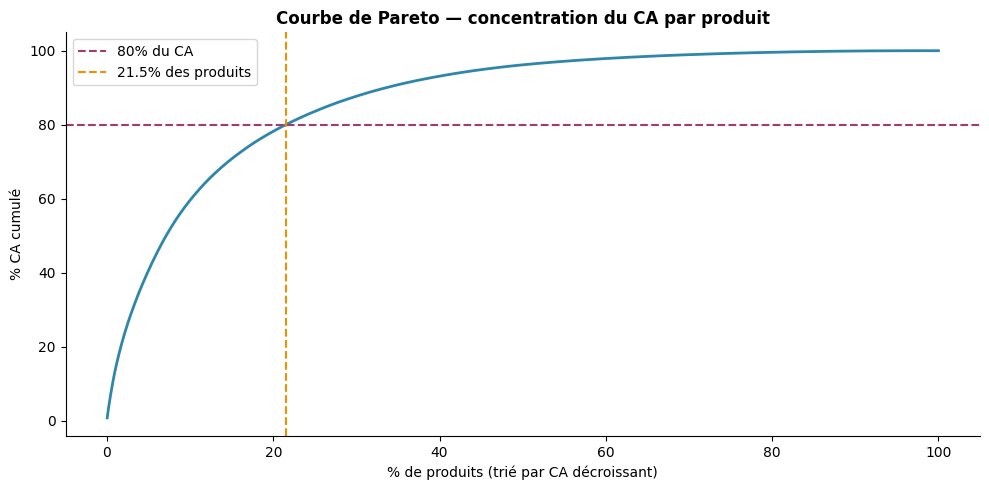

21.5% des produits génèrent 80% du CA (701 produits sur 3265)


In [28]:
ca_produit = df_full.groupby("id_prod")["price"].sum().sort_values(ascending=False)
ca_cum = ca_produit.cumsum() / ca_produit.sum() * 100
n_produits = len(ca_cum)
x = np.arange(1, n_produits + 1) / n_produits * 100
seuil_80 = np.searchsorted(ca_cum.values, 80)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, ca_cum.values, color=COLORS[0], linewidth=2)
ax.axhline(80, color=COLORS[1], linestyle="--", linewidth=1.5, label="80% du CA")
ax.axvline(x[seuil_80], color=COLORS[2], linestyle="--", linewidth=1.5,
           label=f"{x[seuil_80]:.1f}% des produits")
ax.set_title("Courbe de Pareto — concentration du CA par produit", fontsize=12, fontweight="bold")
ax.set_xlabel("% de produits (trié par CA décroissant)")
ax.set_ylabel("% CA cumulé")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "21_pareto_produits.png")
plt.show()

print(f"{x[seuil_80]:.1f}% des produits génèrent 80% du CA ({seuil_80} produits sur {n_produits})")

### 2.7 CA BtoB (proxy : clients à fort volume)

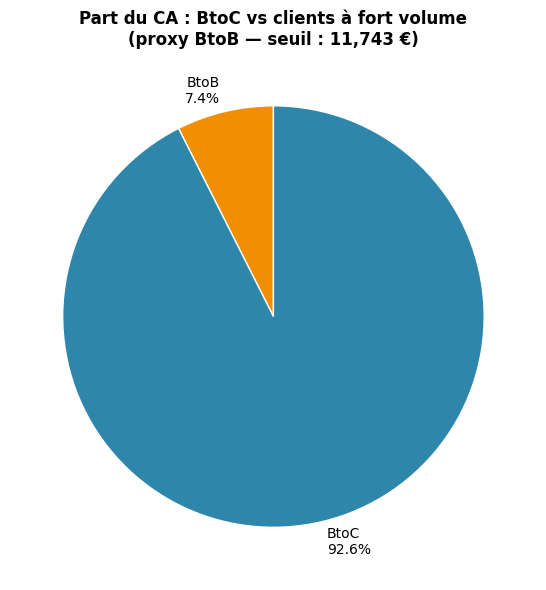

Seuil BtoB (moy + 2σ) : 11,743 €
Clients BtoB proxy    : 4 (0.0% des clients)
CA BtoB               : 0 €
CA BtoC               : 10,972,698 €


In [29]:
ca_client = df_full.groupby("client_id")["price"].sum()
seuil = ca_client.mean() + 2 * ca_client.std()
btob_ids = ca_client[ca_client >= seuil].index

df_full["segment"] = df_full["client_id"].apply(lambda x:"BtoB" if x in btob_ids else "BtoC")
ca_segments = df_full.groupby("segment")["price"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    ca_segments,
    labels=[f"{label}\n{val/ca_segments.sum():.1%}" for label, val in ca_segments.items()],
    colors=["#F18F01", "#2E86AB"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},)
ax.set_title(
    f"Part du CA : BtoC vs clients à fort volume\n(proxy BtoB — seuil : {seuil:,.0f} €)",
    fontweight="bold",)
plt.tight_layout()
plt.savefig(FIG_DIR / "08_ca_btob.png")
plt.show()

print(f"Seuil BtoB (moy + 2σ) : {seuil:,.0f} €")
print(f"Clients BtoB proxy    : {len(btob_ids)} ({len(btob_ids)/len(ca_client):.1%} des clients)")
print(f"CA BtoB               : {ca_segments.get('BtoB (fort volume)', 0):,.0f} €")
print(f"CA BtoC               : {ca_segments.get('BtoC', 0):,.0f} €")

### 2.8 Courbe de Lorenz — concentration du CA

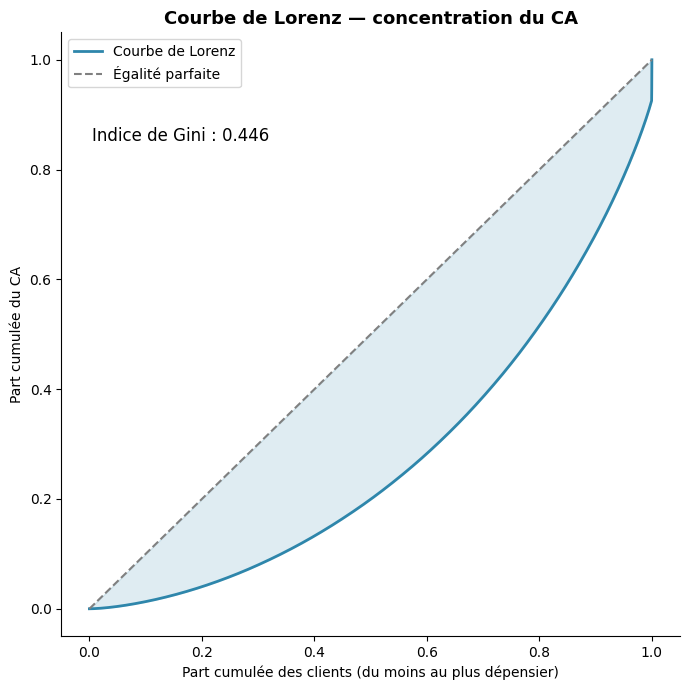

Indice de Gini : 0.446
20% des clients représentent 48.4% du CA


In [30]:
ca_client_sorted = df_full.groupby("client_id")["price"].sum().sort_values()
x = np.linspace(0, 1, len(ca_client_sorted))
y = ca_client_sorted.cumsum() / ca_client_sorted.sum()
gini = float(1 - 2 * np.trapezoid(y, x))

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(x, y.values, color="#2E86AB", linewidth=2, label="Courbe de Lorenz")
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Égalité parfaite")
ax.fill_between(x, y.values, x, alpha=0.15, color="#2E86AB")
ax.set_xlabel("Part cumulée des clients (du moins au plus dépensier)")
ax.set_ylabel("Part cumulée du CA")
ax.set_title("Courbe de Lorenz — concentration du CA", fontsize=13, fontweight="bold")
ax.text(0.05, 0.82, f"Indice de Gini : {gini:.3f}", transform=ax.transAxes, fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "09_lorenz.png")
plt.show()

print(f"Indice de Gini : {gini:.3f}")
p20 = float(y.iloc[int(len(y) * 0.8)])
print(f"20% des clients représentent {1 - p20:.1%} du CA")

### 2.9 Top 20 clients — qui sont-ils ?

In [ ]:
top_clients = (
    df_full.groupby("client_id")
    .agg(ca=("price", "sum"), achats=("id_prod", "count"), panier_moyen=("price", "mean"))
    .assign(panier_moyen=lambda x: x["panier_moyen"].round(2))
    .sort_values("ca", ascending=False)
    .head(24).iloc[4:]
    .reset_index())
top_ids = top_clients["client_id"].tolist()

ca4 = top_clients.iloc[3]["ca"]
ca5 = top_clients.iloc[4]["ca"]
gap_pct = (ca4 - ca5) / ca5 * 100

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_clients["client_id"][::-1], top_clients["ca"][::-1], color="#2E86AB")
ax.set_xlabel("CA total (€)")
ax.set_title("Top 20 clients — CA total", fontweight="bold")
for bar, val in zip(bars, top_clients["ca"][::-1]):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f} €", va="center", fontsize=8)

bar4 = bars[len(bars) - 4]
bar5 = bars[len(bars) - 5]
y4 = bar4.get_y()
y5 = bar5.get_y() + bar5.get_height()
x_annot = top_clients["ca"].max() * 0.6
ax.annotate(
    f"−{gap_pct:.0f}% entre rang 4 et rang 5",
    xy=(x_annot, (y4 + y5) / 2),
    fontsize=9, color="#A23B72", fontweight="bold",
    ha="left", va="center",
    arrowprops=None,
)
ax.axhline(y=(y4 + y5) / 2, color="#A23B72", linestyle="--", linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig(FIG_DIR / "10_top_clients.png", dpi=150, bbox_inches="tight")
plt.show()

print(top_clients[["client_id", "ca", "achats", "panier_moyen"]].to_string(index=False))
print(f"\nÉcart rang 4 → rang 5 : {ca4:,.0f} € vs {ca5:,.0f} € (−{gap_pct:.1f}%)")

### 2.10 Que consomment les top clients ?

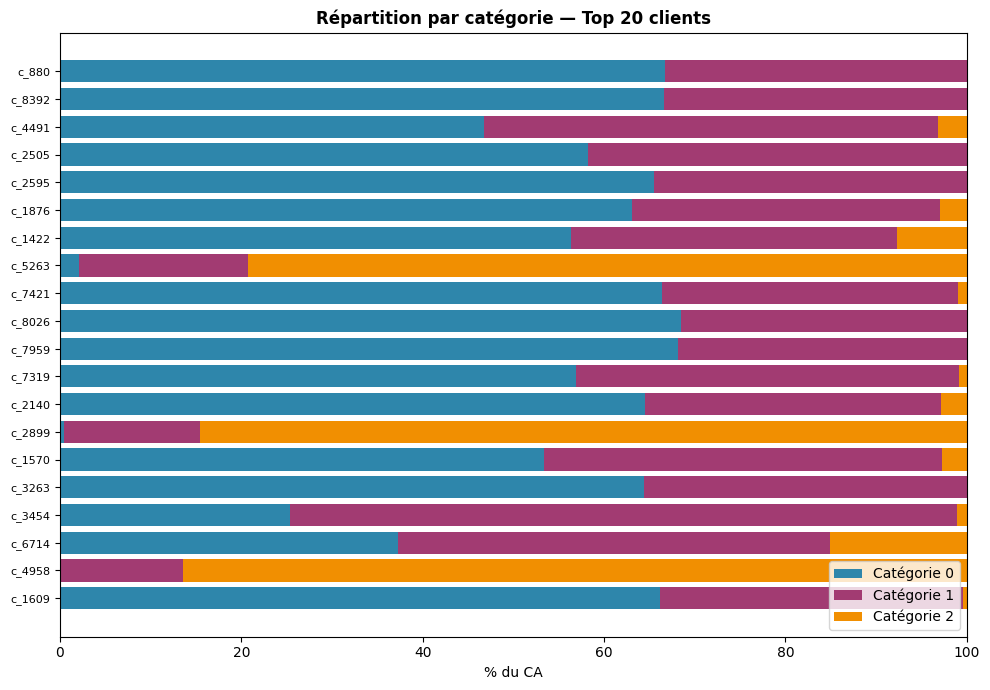

In [32]:
df_top = df_full[df_full["client_id"].isin(top_ids)].copy()
top_categ = (
    df_top.groupby(["client_id", "categ"])["price"]
    .sum()
    .unstack("categ", fill_value=0))
top_categ_pct = top_categ.div(top_categ.sum(axis=1), axis=0) * 100
top_categ_pct = top_categ_pct.loc[top_clients["client_id"]]

fig, ax = plt.subplots(figsize=(10, 7))
left = np.zeros(len(top_categ_pct))
for i, col in enumerate(top_categ_pct.columns):
    ax.barh(range(len(top_categ_pct)), top_categ_pct[col], left=left,
            color=COLORS[i], label=f"Catégorie {col}")
    left += top_categ_pct[col].values
ax.set_yticks(range(len(top_categ_pct)))
ax.set_yticklabels(top_categ_pct.index, fontsize=8)
ax.set_xlabel("% du CA")
ax.set_title("Répartition par catégorie — Top 20 clients", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "11_top_clients_categ.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.11 Clients one-shot vs récurrents

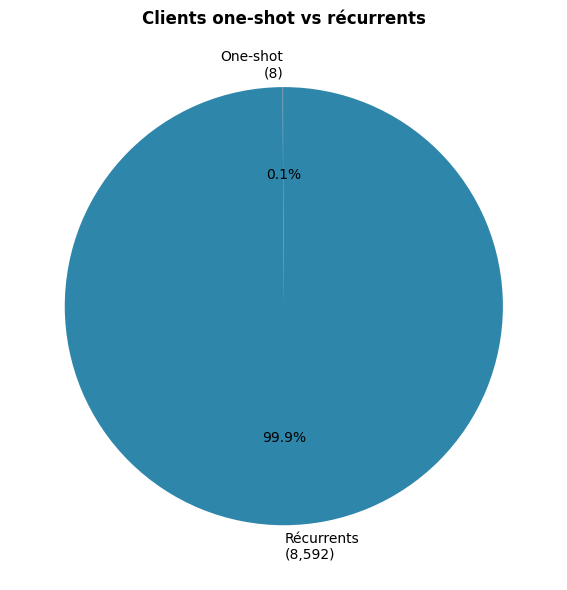

One-shot : 8 clients (0.1%)
Récurrents : 8592 clients (99.9%)


In [33]:
nb_achats = df_full.groupby("client_id").size()
one_shot = (nb_achats == 1).sum()
recurrents = (nb_achats > 1).sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie([one_shot, recurrents],
       labels=[f"One-shot\n({one_shot:,})", f"Récurrents\n({recurrents:,})"],
       colors=[COLORS[1], COLORS[0]],
       autopct="%1.1f%%", startangle=90)
ax.set_title("Clients one-shot vs récurrents", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "22_oneshot_vs_recurrents.png")
plt.show()

print(f"One-shot : {one_shot} clients ({one_shot/(one_shot+recurrents)*100:.1f}%)")
print(f"Récurrents : {recurrents} clients ({recurrents/(one_shot+recurrents)*100:.1f}%)")

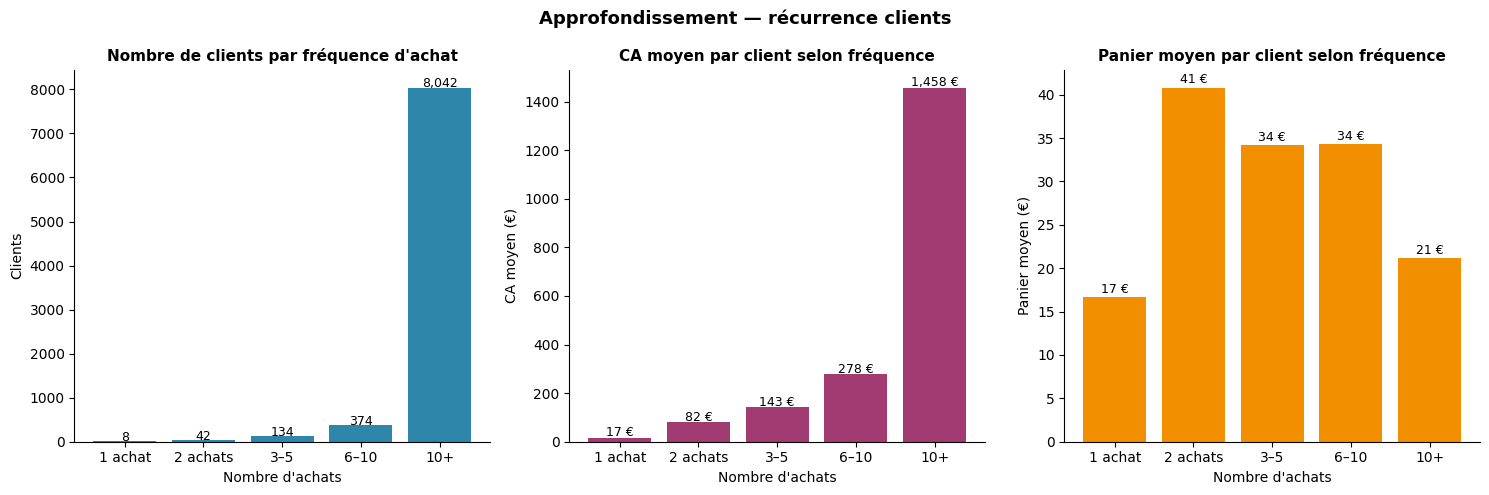

          clients  ca_moyen  panier_moyen
segment                                  
1 achat         8      16.7          16.7
2 achats       42      81.7          40.8
3–5           134     142.7          34.2
6–10          374     278.0          34.3
10+          8042    1458.2          21.2


In [34]:
client_stats = (
    df_full.groupby("client_id")
    .agg(nb_achats=("id_prod", "count"), ca=("price", "sum"))
    .assign(panier=lambda x: x["ca"] / x["nb_achats"])
)
client_stats["segment"] = pd.cut(
    client_stats["nb_achats"],
    bins=[0, 1, 2, 5, 10, client_stats["nb_achats"].max()],
    labels=["1 achat", "2 achats", "3–5", "6–10", "10+"],
)

freq_dist = client_stats["segment"].value_counts().sort_index()
ca_segment = client_stats.groupby("segment", observed=True)["ca"].mean()
panier_segment = client_stats.groupby("segment", observed=True)["panier"].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(freq_dist.index.astype(str), freq_dist.values, color=COLORS[0])
axes[0].set_title("Nombre de clients par fréquence d'achat", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Nombre d'achats")
axes[0].set_ylabel("Clients")
for i, v in enumerate(freq_dist.values):
    axes[0].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].bar(ca_segment.index.astype(str), ca_segment.values, color=COLORS[1])
axes[1].set_title("CA moyen par client selon fréquence", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Nombre d'achats")
axes[1].set_ylabel("CA moyen (€)")
for i, v in enumerate(ca_segment.values):
    axes[1].text(i, v + 5, f"{v:,.0f} €", ha="center", fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[2].bar(panier_segment.index.astype(str), panier_segment.values, color=COLORS[2])
axes[2].set_title("Panier moyen par client selon fréquence", fontsize=11, fontweight="bold")
axes[2].set_xlabel("Nombre d'achats")
axes[2].set_ylabel("Panier moyen (€)")
for i, v in enumerate(panier_segment.values):
    axes[2].text(i, v + 0.5, f"{v:,.0f} €", ha="center", fontsize=9)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

plt.suptitle("Approfondissement — récurrence clients", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "22b_recurrence_approfondie.png", dpi=150, bbox_inches="tight")
plt.show()

print(client_stats.groupby("segment", observed=True)[["nb_achats", "ca", "panier"]]
      .agg(clients=("nb_achats", "count"), ca_moyen=("ca", "mean"), panier_moyen=("panier", "mean"))
      .round(1).to_string())

### 2.12 Segmentation RFM

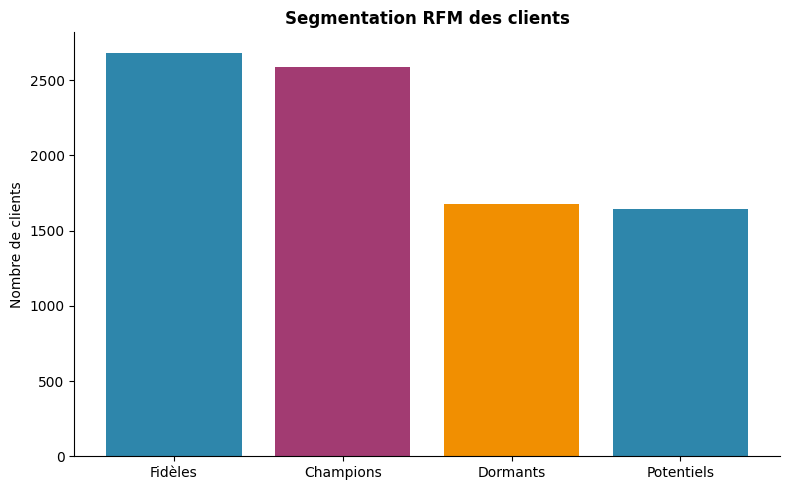

            recence  frequence  montant
segment                                
Champions       6.5      167.6   2650.8
Dormants      118.0       16.6    343.1
Fidèles        18.3       60.3   1215.3
Potentiels     39.7       33.5    698.6


In [35]:

rfm = (
    df_full.groupby("client_id")
    .agg(
        recence=("date", lambda x: (date_ref - x.max()).days),
        frequence=("price", "count"),
        montant=("price", "sum"),
    )
    .reset_index()
)

rfm["r_score"] = pd.qcut(rfm["recence"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["f_score"] = pd.qcut(rfm["frequence"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["m_score"] = pd.qcut(rfm["montant"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["rfm_score"] = rfm["r_score"] + rfm["f_score"] + rfm["m_score"]

def segment_rfm(score):
    if score >= 10:
        return "Champions"
    elif score >= 7:
        return "Fidèles"
    elif score >= 5:
        return "Potentiels"
    else:
        return "Dormants"

rfm["segment"] = rfm["rfm_score"].apply(segment_rfm)

seg_counts = rfm["segment"].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(seg_counts.index, seg_counts.values, color=COLORS * 2)
ax.set_title("Segmentation RFM des clients", fontsize=12, fontweight="bold")
ax.set_ylabel("Nombre de clients")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "23_rfm_segments.png")
plt.show()

print(rfm.groupby("segment")[["recence", "frequence", "montant"]].mean().round(1))

### 2.13 Cohortes — taux de rétention mensuelle

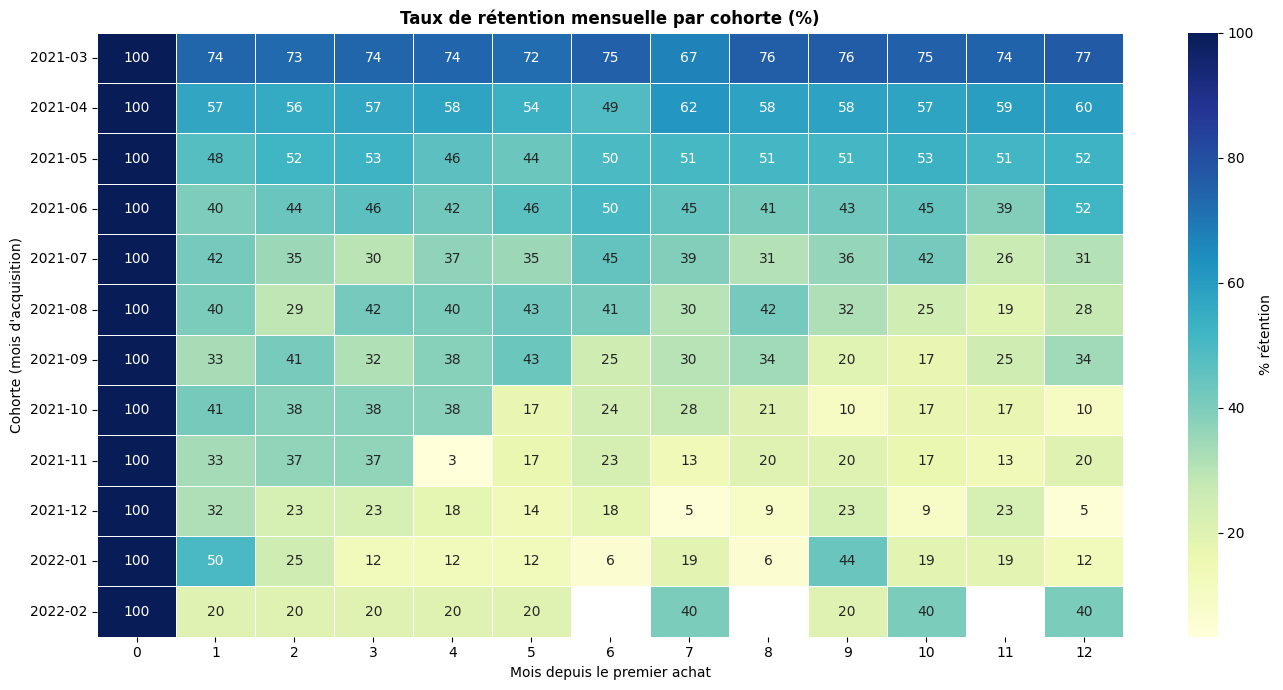

In [36]:
df_full["mois_achat"] = df_full["date"].dt.to_period("M")
premiere_commande = df_full.groupby("client_id")["mois_achat"].min().rename("cohorte")
df_cohort = df_full.join(premiere_commande, on="client_id")
df_cohort["periode"] = (df_cohort["mois_achat"] - df_cohort["cohorte"]).apply(lambda x: x.n)

cohort_data = (
    df_cohort.groupby(["cohorte", "periode"])["client_id"]
    .nunique()
    .unstack()
)
cohort_pct = cohort_data.div(cohort_data[0], axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cohort_pct.iloc[:, :13], annot=True, fmt=".0f", cmap="YlGnBu",
            ax=ax, linewidths=0.5, cbar_kws={"label": "% rétention"})
ax.set_title("Taux de rétention mensuelle par cohorte (%)", fontsize=12, fontweight="bold")
ax.set_xlabel("Mois depuis le premier achat")
ax.set_ylabel("Cohorte (mois d'acquisition)")
plt.tight_layout()
plt.savefig(FIG_DIR / "24_cohortes_retention.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.14 Temporalité des achats

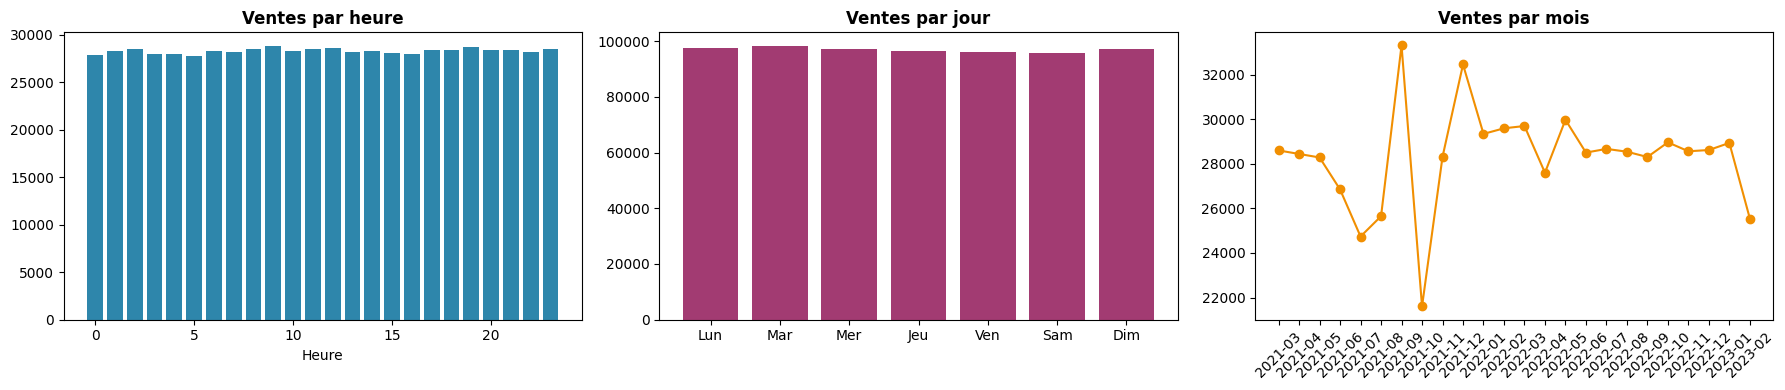

In [37]:
df_full["hour"] = df_full["date"].dt.hour
df_full["dow"] = df_full["date"].dt.dayofweek
df_full["day_name"] = df_full["date"].dt.day_name()
df_full["week"] = df_full["date"].dt.isocalendar().week.astype(int)
df_full["month"] = df_full["date"].dt.month
df_full["year_month"] = df_full["date"].dt.to_period("M")

# Par heure
ventes_heure = df_full.groupby("hour").size()

# Par jour de la semaine
ventes_dow = df_full.groupby("day_name").size().reindex(DOW_ORDER)

# Par mois
ventes_mois = df_full.groupby("year_month").size()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].bar(ventes_heure.index, ventes_heure.values, color="#2E86AB")
axes[0].set_title("Ventes par heure", fontweight="bold")
axes[0].set_xlabel("Heure")
axes[1].bar(DOW_FR, ventes_dow.values, color="#A23B72")
axes[1].set_title("Ventes par jour", fontweight="bold")
axes[2].plot(ventes_mois.index.astype(str), ventes_mois.values, marker="o", color="#F18F01")
axes[2].set_title("Ventes par mois", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()

### 2.15 Panier moyen & volume de ventes par catégorie

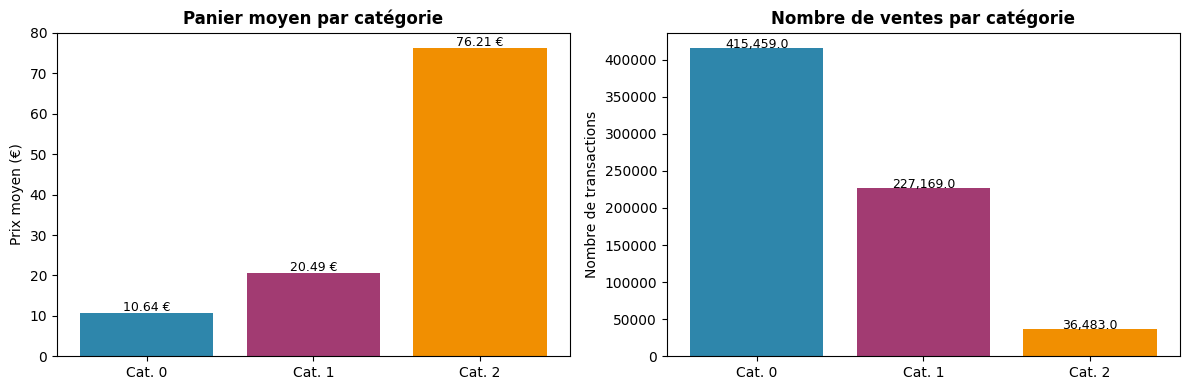

       panier_moyen  nb_ventes    ca_total
categ                                     
0             10.64     415459  4419730.97
1             20.49     227169  4653722.69
2             76.21      36483  2780275.02


In [38]:
stats_categ = df_full.groupby("categ")["price"].agg(
    panier_moyen="mean",
    nb_ventes="count",
    ca_total="sum"
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar([f"Cat. {c}" for c in stats_categ.index], stats_categ["panier_moyen"],
            color=COLORS[:len(stats_categ)])
axes[0].set_title("Panier moyen par catégorie", fontweight="bold")
axes[0].set_ylabel("Prix moyen (€)")
for i, (_, row) in enumerate(stats_categ.iterrows()):
    axes[0].text(i, row["panier_moyen"] + 0.5, f"{row['panier_moyen']:.2f} €",
                 ha="center", fontsize=9)

axes[1].bar([f"Cat. {c}" for c in stats_categ.index], stats_categ["nb_ventes"],
            color=COLORS[:len(stats_categ)])
axes[1].set_title("Nombre de ventes par catégorie", fontweight="bold")
axes[1].set_ylabel("Nombre de transactions")
for i, (_, row) in enumerate(stats_categ.iterrows()):
    axes[1].text(i, row["nb_ventes"] + 50, f"{row['nb_ventes']:,}",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "13_stats_categ.png", dpi=150, bbox_inches="tight")
plt.show()
print(stats_categ.to_string())

### 2.16 Profil genre par catégorie

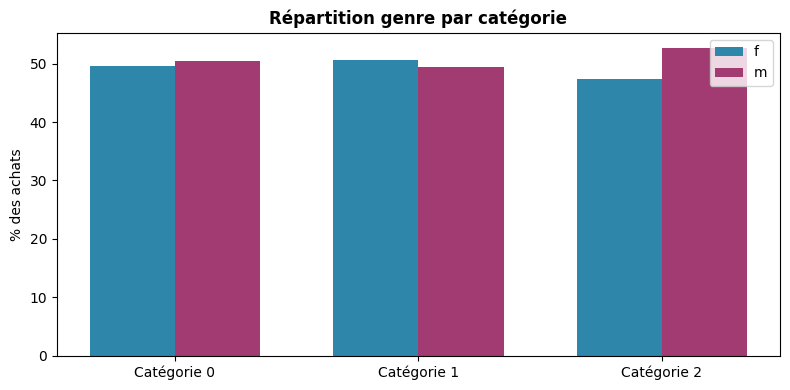

In [39]:
genre_categ = (
    df_full.groupby(["categ", "sex"])["client_id"]
    .count()
    .unstack("sex", fill_value=0))
genre_categ_pct = genre_categ.div(genre_categ.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(genre_categ_pct))
width = 0.35
for i, sex in enumerate(genre_categ_pct.columns):
    ax.bar(x + i * width, genre_categ_pct[sex], width,
           label=sex, color=COLORS[i])
ax.set_xticks(x + width / 2)
ax.set_xticklabels([f"Catégorie {c}" for c in genre_categ_pct.index])
ax.set_ylabel("% des achats")
ax.set_title("Répartition genre par catégorie", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "14_genre_categ.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.17 Âge par catégorie achetée (boxplot)

/tmp/ipykernel_26470/2900367973.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, patch_artist=True, labels=[f"Catégorie {c}" for c in categories])


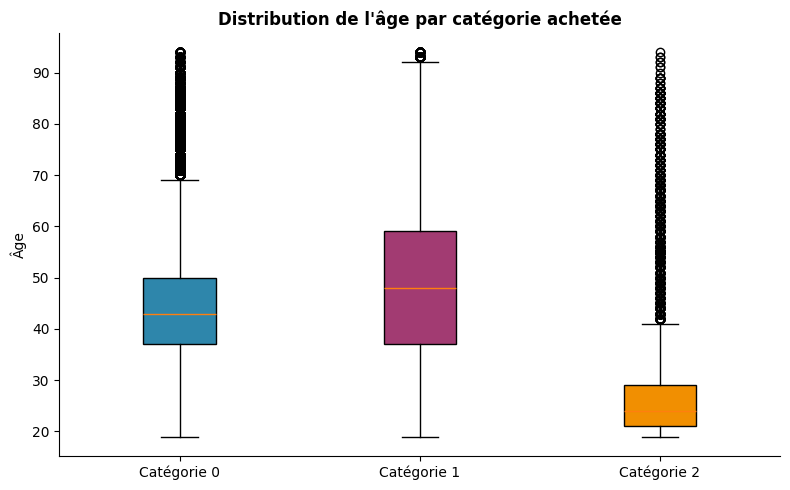

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
categories = sorted(df_full["categ"].unique())
data_box = [df_full[df_full["categ"] == c]["age"].dropna() for c in categories]
bp = ax.boxplot(data_box, patch_artist=True, labels=[f"Catégorie {c}" for c in categories])
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color)
ax.set_title("Distribution de l'âge par catégorie achetée", fontsize=12, fontweight="bold")
ax.set_ylabel("Âge")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "26_age_par_categorie_boxplot.png")
plt.show()

### 2.18 Top 10 produits vendus par catégorie

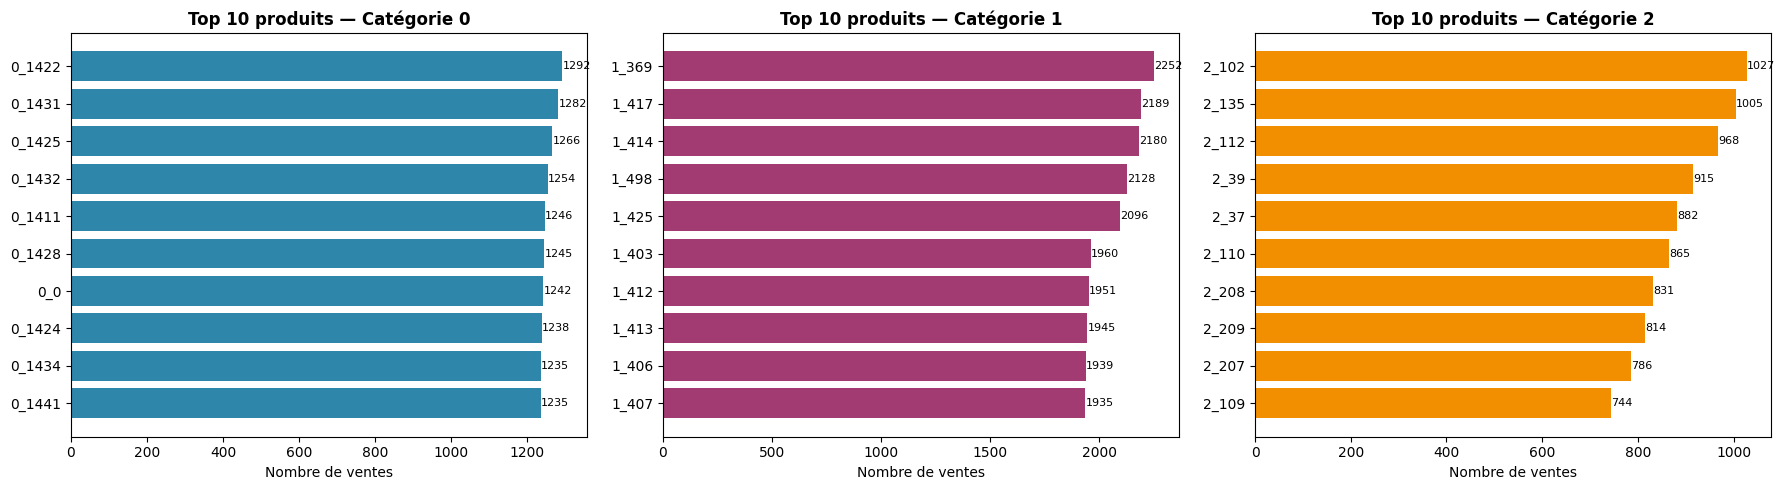

In [41]:
categories = sorted(df_full["categ"].unique())
fig, axes = plt.subplots(1, len(categories), figsize=(6 * len(categories), 5))
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):
    top_prod = (
        df_full[df_full["categ"] == cat]
        .groupby("id_prod")["id_prod"]
        .count()
        .rename("ventes")
        .nlargest(10)
        .sort_values()
    )
    ax.barh(top_prod.index, top_prod.values, color=COLORS[categories.index(cat)])
    ax.set_title(f"Top 10 produits — Catégorie {cat}", fontweight="bold")
    ax.set_xlabel("Nombre de ventes")
    for bar, val in zip(ax.patches, top_prod.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "15_top_produits_categ.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3. Analyses Julie — Corrélations comportementales <a id='3-julie'></a>

### 3.1 Genre ↔ Catégorie achetée (Chi²)

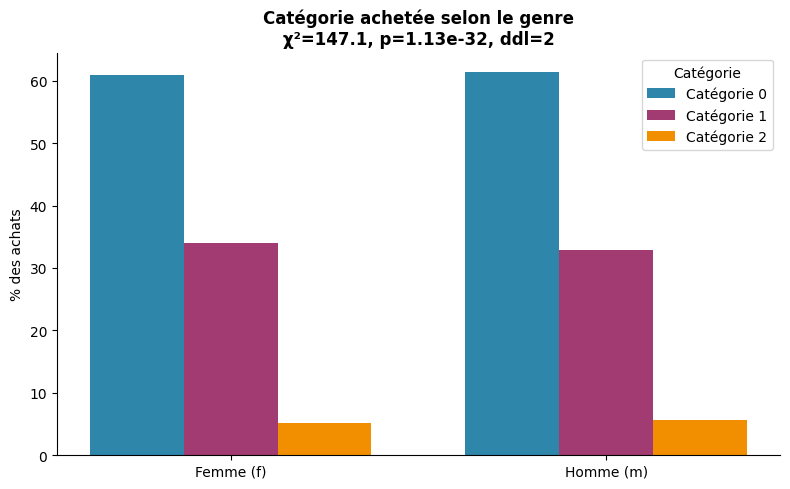

Chi² = 147.12, p = 0.0000, ddl = 2
Lien significatif (p < 0.05)

Répartition % par genre :
categ     0     1    2
sex                   
f      60.9  34.0  5.1
m      61.4  32.9  5.6


In [42]:
genre_categ = df_full.groupby(["sex", "categ"]).size().unstack("categ", fill_value=0)
genre_categ_pct = genre_categ.div(genre_categ.sum(axis=1), axis=0) * 100
chi2_val, p_val, dof, _ = stats.chi2_contingency(genre_categ)

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(genre_categ_pct.index))
width = 0.25
for i, col in enumerate(genre_categ_pct.columns):
    ax.bar(x_pos + i * width, genre_categ_pct[col], width, label=f"Catégorie {col}", color=COLORS[i])
ax.set_xticks(x_pos + width)
ax.set_xticklabels(["Femme (f)", "Homme (m)"])
ax.set_title(
    f"Catégorie achetée selon le genre\nχ²={chi2_val:.1f}, p={p_val:.2e}, ddl={dof}",
    fontsize=12, fontweight="bold",)

ax.set_ylabel("% des achats")
ax.legend(title="Catégorie")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "10_genre_categorie.png")
plt.show()

print(f"Chi² = {chi2_val:.2f}, p = {p_val:.4f}, ddl = {dof}")
print("Lien significatif (p < 0.05)" if p_val < 0.05 else "Pas de lien significatif (p ≥ 0.05)")
print("\nRépartition % par genre :")
print(genre_categ_pct.round(1).to_string())

### 3.2 Tranche d'âge ↔ Catégorie achetée (Chi²)

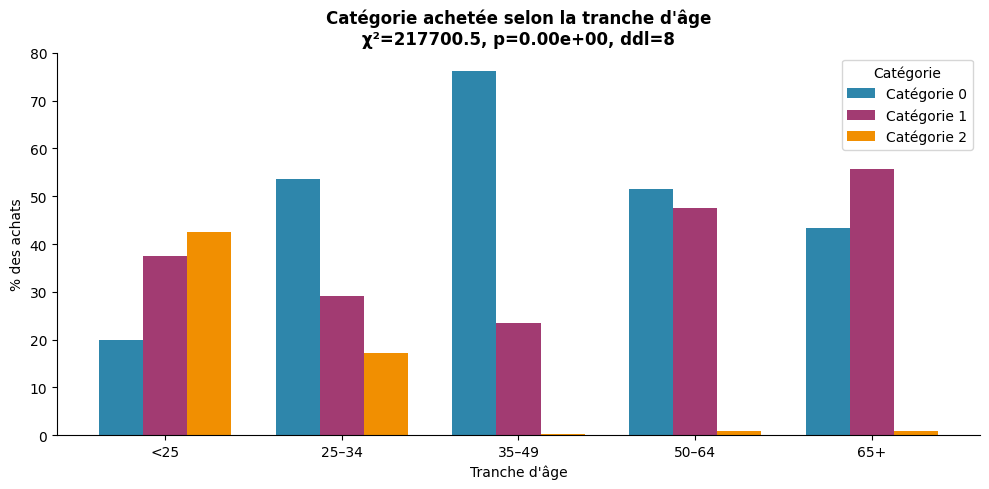

Chi² = 217700.54, p = 0.0000, ddl = 8
Lien significatif (p < 0.05)

Répartition % par tranche d'âge :
categ           0     1     2
tranche_age                  
<25          20.0  37.5  42.5
25–34        53.7  29.1  17.2
35–49        76.2  23.4   0.3
50–64        51.4  47.6   0.9
65+          43.4  55.7   0.9


In [43]:
df_full["tranche_age"] = pd.cut(df_full["age"], bins=age_bins, labels=age_labels, right=False)

age_categ = df_full.groupby(["tranche_age", "categ"], observed=True).size().unstack("categ", fill_value=0)
age_categ_pct = age_categ.div(age_categ.sum(axis=1), axis=0) * 100
chi2_val, p_val, dof, _ = stats.chi2_contingency(age_categ)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(age_categ_pct.index))
width = 0.25
for i, col in enumerate(age_categ_pct.columns):
    ax.bar(x_pos + i * width, age_categ_pct[col], width, label=f"Catégorie {col}", color=COLORS[i])
ax.set_xticks(x_pos + width)
ax.set_xticklabels(age_labels)
ax.set_title(
    f"Catégorie achetée selon la tranche d'âge\nχ²={chi2_val:.1f}, p={p_val:.2e}, ddl={dof}",
    fontsize=12, fontweight="bold",
)
ax.set_ylabel("% des achats")
ax.set_xlabel("Tranche d'âge")
ax.legend(title="Catégorie")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_age_categorie.png")
plt.show()

print(f"Chi² = {chi2_val:.2f}, p = {p_val:.4f}, ddl = {dof}")
print("Lien significatif (p < 0.05)" if p_val < 0.05 else "Pas de lien significatif (p ≥ 0.05)")
print("\nRépartition % par tranche d'âge :")
print(age_categ_pct.round(1).to_string())

### 3.3 Âge ↔ CA total (Pearson)

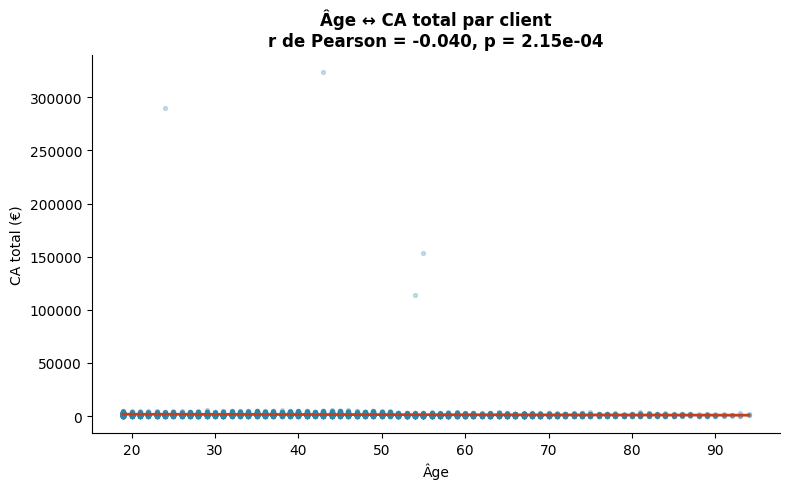

r de Pearson = -0.040, p = 0.0002
Corrélation significative (p < 0.05)


In [44]:
# légère tendance négative, mais négligeable — l'âge n'explique pas le CA.
client_stats = df_full.groupby("client_id").agg(
    ca_total=("price", "sum"),
    age=("age", "first")
).reset_index()

r, p_val = stats.pearsonr(client_stats["age"], client_stats["ca_total"])
m, b = np.polyfit(client_stats["age"], client_stats["ca_total"], 1)
x_line = np.array([client_stats["age"].min(), client_stats["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_stats["age"], client_stats["ca_total"], alpha=0.25, s=8, color="#2E86AB")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ CA total par client\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("CA total (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_age_ca_total.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")

### 3.4 Âge ↔ Fréquence d'achat (Pearson)

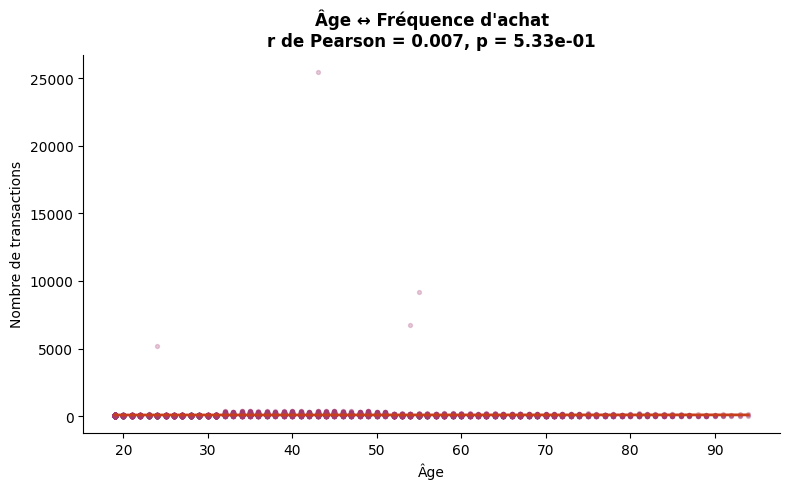

r de Pearson = 0.007, p = 0.5331
Pas de corrélation significative (p ≥ 0.05)
Moy. transactions par client : 79.0


In [45]:
#Conclusion : le nombre de transactions n'explique pas le CA total.

client_freq = df_full.groupby("client_id").agg(
    nb_transactions=("id_prod", "count"),
    age=("age", "first")).reset_index()

r, p_val = stats.pearsonr(client_freq["age"], client_freq["nb_transactions"])
m, b = np.polyfit(client_freq["age"], client_freq["nb_transactions"], 1)
x_line = np.array([client_freq["age"].min(), client_freq["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_freq["age"], client_freq["nb_transactions"], alpha=0.25, s=8, color="#A23B72")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ Fréquence d'achat\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Nombre de transactions")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "12_age_frequence.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Moy. transactions par client : {client_freq['nb_transactions'].mean():.1f}")

### 3.5 Âge ↔ Panier moyen (Pearson)

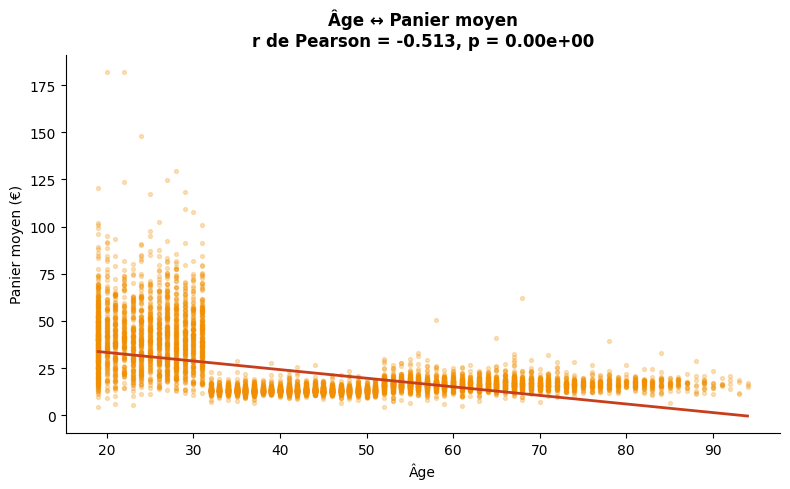

r de Pearson = -0.513, p = 0.0000
Corrélation significative (p < 0.05)
Panier moyen global : 22.02 €


In [46]:
client_panier = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    age=("age", "first")).reset_index()

r, p_val = stats.pearsonr(client_panier["age"], client_panier["panier_moyen"])
m, b = np.polyfit(client_panier["age"], client_panier["panier_moyen"], 1)
x_line = np.array([client_panier["age"].min(), client_panier["age"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_panier["age"], client_panier["panier_moyen"], alpha=0.25, s=8, color="#F18F01")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Âge ↔ Panier moyen\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "13_age_panier_moyen.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Panier moyen global : {client_panier['panier_moyen'].mean():.2f} €")

### 3.6 Ancienneté ↔ CA total (Pearson)

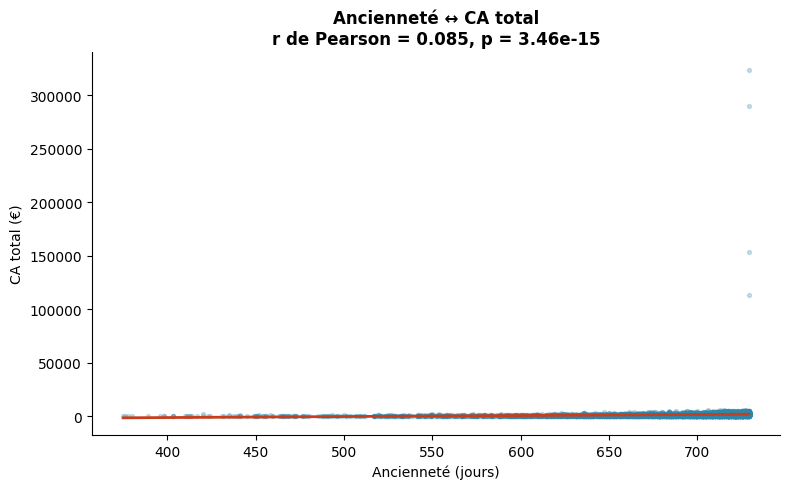

r de Pearson = 0.085, p = 0.0000
Corrélation significative (p < 0.05)
Pente : 9.49 € de CA par jour d'ancienneté supplémentaire


In [47]:
ancien = df_full.groupby("client_id").agg(
    ca_total=("price", "sum"),
    premiere_commande=("date", "min")
).reset_index()
ancien["anciennete_jours"] = (date_ref - ancien["premiere_commande"]).dt.days

r, p_val = stats.pearsonr(ancien["anciennete_jours"], ancien["ca_total"])
m, b = np.polyfit(ancien["anciennete_jours"], ancien["ca_total"], 1)
x_line = np.array([ancien["anciennete_jours"].min(), ancien["anciennete_jours"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(ancien["anciennete_jours"], ancien["ca_total"], alpha=0.25, s=8, color="#2E86AB")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Ancienneté ↔ CA total\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Ancienneté (jours)")
ax.set_ylabel("CA total (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "14_anciennete_ca.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Pente : {m:.2f} € de CA par jour d'ancienneté supplémentaire")

### 3.7 Ancienneté ↔ Panier moyen (Pearson)

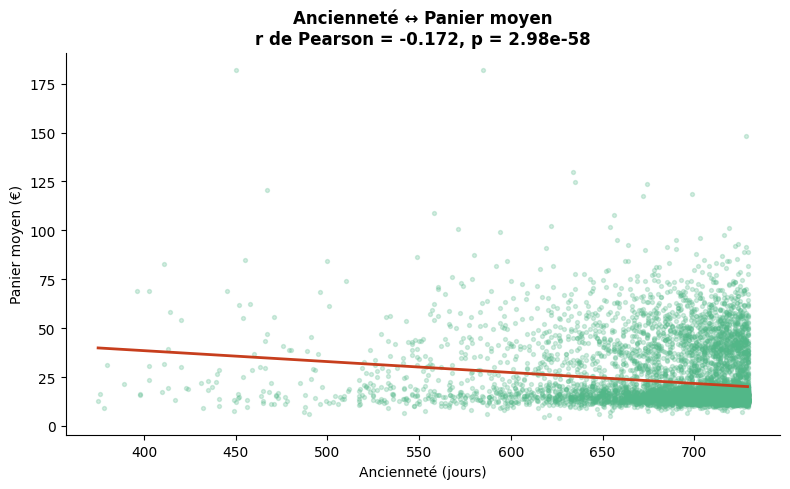

r de Pearson = -0.172, p = 0.0000
Corrélation significative (p < 0.05)
Pente : -0.06 € de panier moyen par jour d'ancienneté supplémentaire


In [48]:
client_anciennete2 = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    premiere_commande=("date", "min")
).reset_index()
client_anciennete2["anciennete_jours"] = (date_ref - client_anciennete2["premiere_commande"]).dt.days

r, p_val = stats.pearsonr(client_anciennete2["anciennete_jours"], client_anciennete2["panier_moyen"])
m, b = np.polyfit(client_anciennete2["anciennete_jours"], client_anciennete2["panier_moyen"], 1)
x_line = np.array([client_anciennete2["anciennete_jours"].min(), client_anciennete2["anciennete_jours"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_anciennete2["anciennete_jours"], client_anciennete2["panier_moyen"], alpha=0.25, s=8, color="#52B788")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Ancienneté ↔ Panier moyen\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Ancienneté (jours)")
ax.set_ylabel("Panier moyen (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_anciennete_panier.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Pente : {m:.2f} € de panier moyen par jour d'ancienneté supplémentaire")

### 3.8 Fréquence d'achat ↔ Panier moyen (Pearson)

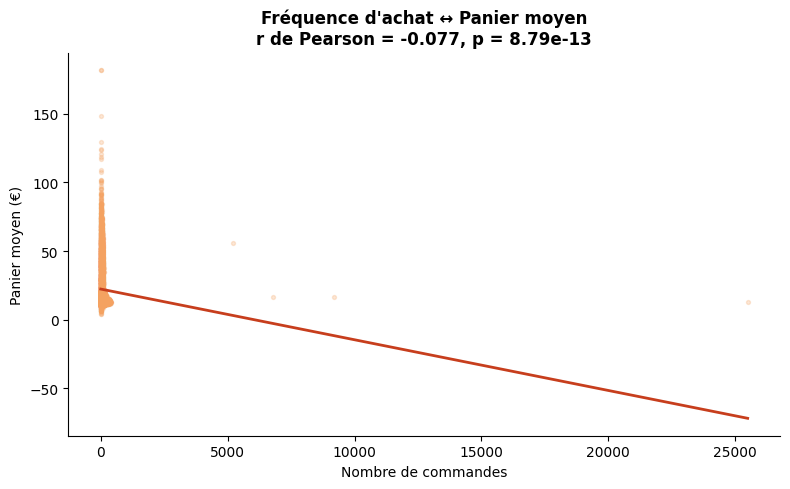

r de Pearson = -0.077, p = 0.0000
Corrélation significative (p < 0.05)
Pente : -0.00 € de panier moyen par commande supplémentaire


In [49]:
client_freq2 = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    nb_commandes=("price", "count")
).reset_index()

r, p_val = stats.pearsonr(client_freq2["nb_commandes"], client_freq2["panier_moyen"])
m, b = np.polyfit(client_freq2["nb_commandes"], client_freq2["panier_moyen"], 1)
x_line = np.array([client_freq2["nb_commandes"].min(), client_freq2["nb_commandes"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_freq2["nb_commandes"], client_freq2["panier_moyen"], alpha=0.25, s=8, color="#F4A261")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Fréquence d'achat ↔ Panier moyen\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Nombre de commandes")
ax.set_ylabel("Panier moyen (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "16_frequence_panier.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Pente : {m:.2f} € de panier moyen par commande supplémentaire")

### 3.9 Délai moyen entre commandes ↔ CA total (Pearson)

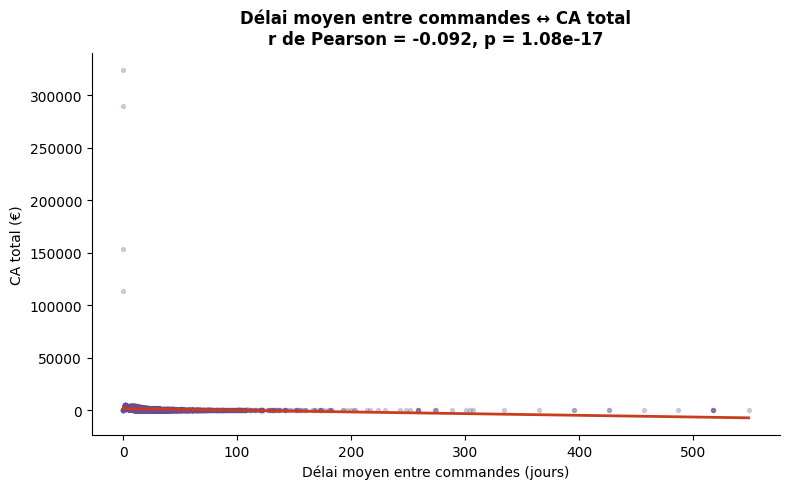

r de Pearson = -0.092, p = 0.0000
Corrélation significative (p < 0.05)
Pente : -16.06 € de CA par jour de délai supplémentaire


In [50]:
delai_moyen = (
    df_full.sort_values("date")
    .groupby("client_id")["date"]
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index(name="delai_moyen_jours"))
client_delai = delai_moyen.merge(
    df_full.groupby("client_id")["price"].sum().reset_index(name="ca_total"),
    on="client_id").dropna()

r, p_val = stats.pearsonr(client_delai["delai_moyen_jours"], client_delai["ca_total"])
m, b = np.polyfit(client_delai["delai_moyen_jours"], client_delai["ca_total"], 1)
x_line = np.array([client_delai["delai_moyen_jours"].min(), client_delai["delai_moyen_jours"].max()])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(client_delai["delai_moyen_jours"], client_delai["ca_total"], alpha=0.25, s=8, color="#6A4C93")
ax.plot(x_line, m * x_line + b, color="#C73E1D", linewidth=2)
ax.set_title(f"Délai moyen entre commandes ↔ CA total\nr de Pearson = {r:.3f}, p = {p_val:.2e}", fontsize=12, fontweight="bold")
ax.set_xlabel("Délai moyen entre commandes (jours)")
ax.set_ylabel("CA total (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_delai_ca.png")
plt.show()

print(f"r de Pearson = {r:.3f}, p = {p_val:.4f}")
print("Corrélation significative (p < 0.05)" if p_val < 0.05 else "Pas de corrélation significative (p ≥ 0.05)")
print(f"Pente : {m:.2f} € de CA par jour de délai supplémentaire")

### 3.10 Genre ↔ Panier moyen (Mann-Whitney)

/tmp/ipykernel_26470/4294555705.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([h_panier, f_panier], labels=["Homme", "Femme"], patch_artist=True,


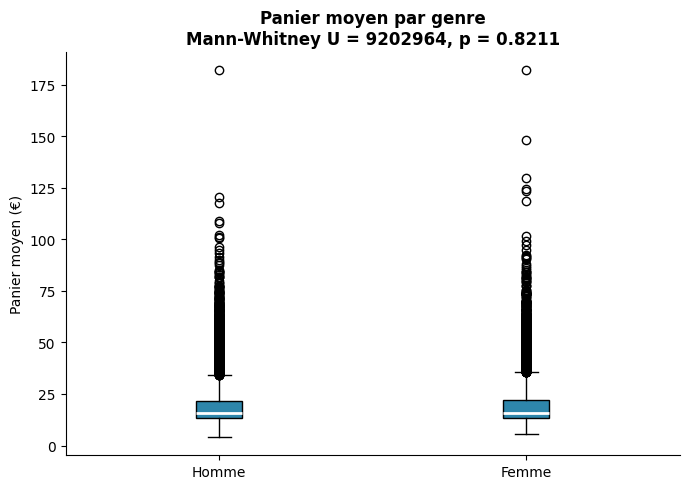

Homme : 22.03€ en moyenne — Femme : 22.02€ en moyenne
→ Pas de différence significative (p ≥ 0.05)


In [51]:
client_genre = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    sex=("sex", "first")
)
h_panier = client_genre[client_genre["sex"] == "m"]["panier_moyen"]
f_panier = client_genre[client_genre["sex"] == "f"]["panier_moyen"]

u_stat, p_val = stats.mannwhitneyu(h_panier, f_panier, alternative="two-sided")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([h_panier, f_panier], labels=["Homme", "Femme"], patch_artist=True,
           boxprops=dict(facecolor=COLORS[0]), medianprops=dict(color="white", linewidth=2))
ax.set_title(f"Panier moyen par genre\nMann-Whitney U = {u_stat:.0f}, p = {p_val:.4f}",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Panier moyen (€)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "27_genre_panier_mannwhitney.png")
plt.show()

print(f"Homme : {h_panier.mean():.2f}€ en moyenne — Femme : {f_panier.mean():.2f}€ en moyenne")
print("→", "Différence significative (p < 0.05)" if p_val < 0.05 else "Pas de différence significative (p ≥ 0.05)")

### 3.11 Tranche d'âge ↔ Panier moyen (Kruskal-Wallis)

/tmp/ipykernel_26470/158768488.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=age_labels, patch_artist=True)


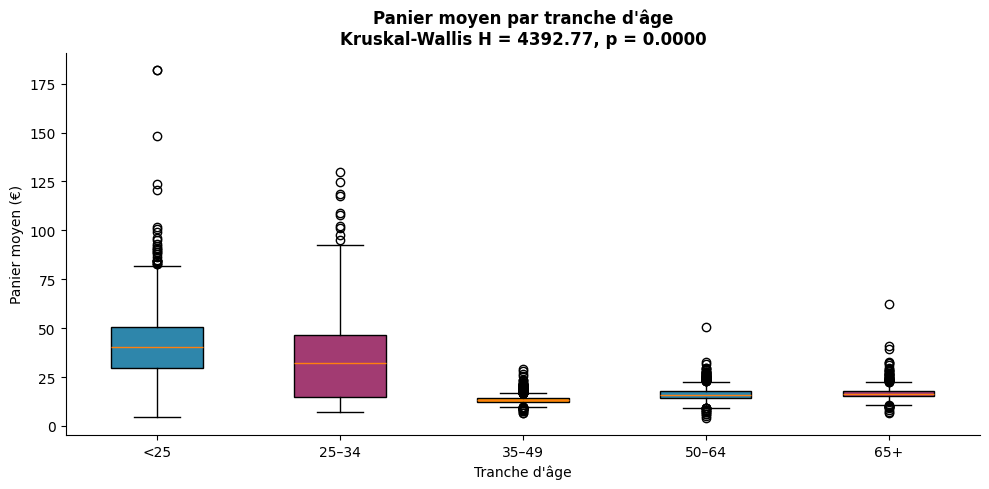

→ Différence significative entre tranches (p < 0.05)


In [52]:

client_age_panier = df_full.groupby("client_id").agg(
    panier_moyen=("price", "mean"),
    age=("age", "first")
).reset_index()
client_age_panier["tranche_age"] = pd.cut(
    client_age_panier["age"], bins=age_bins, labels=age_labels, right=False
)

groupes = [g["panier_moyen"].values for _, g in client_age_panier.groupby("tranche_age", observed=True)]
h_stat, p_val = stats.kruskal(*groupes)

fig, ax = plt.subplots(figsize=(10, 5))
data_box = [g["panier_moyen"].values for _, g in client_age_panier.groupby("tranche_age", observed=True)]
bp = ax.boxplot(data_box, labels=age_labels, patch_artist=True)
for patch, color in zip(bp["boxes"], COLORS * 2):
    patch.set_facecolor(color)
ax.set_title(f"Panier moyen par tranche d'âge\nKruskal-Wallis H = {h_stat:.2f}, p = {p_val:.4f}",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Panier moyen (€)")
ax.set_xlabel("Tranche d'âge")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "29_age_panier_kruskal.png")
plt.show()

print("→", "Différence significative entre tranches (p < 0.05)" if p_val < 0.05 else "Pas de différence significative (p ≥ 0.05)")